In [1]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [5]:
def lda_extract_features_from_npz(npz_path, fs=250, band=(8,25)):
    """
    Loads .npz file and extracts lateralization features.
    
    Returns:
        features (n_samples, 3)
        y (n_samples,)
    """

    data = np.load(npz_path)
    X = data["X"]         # (samples, time, channels)
    y = data["y"]

    n_samples, _, n_channels = X.shape
    band_power = np.zeros((n_samples, n_channels))

    # Compute band power via Welch
    for s in range(n_samples):
        for ch in range(n_channels):

            freqs, psd = welch(X[s,:,ch], fs=fs, nperseg=512)
            mask = (freqs >= band[0]) & (freqs <= band[1])
            band_power[s,ch] = np.trapz(psd[mask], freqs[mask])

    # Log-power improves stability
    band_power = np.log(band_power + 1e-10)

    # Lateralization indices
    LI_34 = (band_power[:,2] - band_power[:,3]) / (band_power[:,2] + band_power[:,3])
    LI_56 = (band_power[:,4] - band_power[:,5]) / (band_power[:,4] + band_power[:,5])
    LI_78 = (band_power[:,6] - band_power[:,7]) / (band_power[:,6] + band_power[:,7])

    features = np.vstack([LI_34, LI_56, LI_78]).T

    return features, y

In [6]:

def calibrate_from_npz(npz_path,
                       fs=250,
                       margin_factor=0.5,
                       show_kpi=False,
                       show_lda=False):
    """
    Calibrates LDA-based 3-class predictor (Left/Right/Neutral)
    using only Left and Right calibration data.
    """

    # --- Extract features ---
    features, y = lda_extract_features_from_npz(npz_path, fs)

    # --- Normalize ---
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)

    # --- Train LDA ---
    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(features_norm, y)

    LD1 = lda.transform(features_norm).flatten()

    # --- Compute midpoint ---
    mean0 = LD1[y==0].mean()
    mean1 = LD1[y==1].mean()
    midpoint = (mean0 + mean1) / 2

    sigma = np.std(LD1)
    margin = margin_factor * sigma

    # --- 3-class decision ---
    y_pred = np.zeros(len(LD1))

    for i, val in enumerate(LD1):
        if val < midpoint - margin:
            y_pred[i] = 0
        elif val > midpoint + margin:
            y_pred[i] = 1
        else:
            y_pred[i] = 2

    # --- KPIs ---
    if show_kpi:
        mask_confident = y_pred != 2
        print("Confident Accuracy:",
              accuracy_score(y[mask_confident], y_pred[mask_confident]))

        print("\nConfusion Matrix (confident only):")
        print(confusion_matrix(y[mask_confident], y_pred[mask_confident]))

        print("\nClassification Report:")
        print(classification_report(y[mask_confident], y_pred[mask_confident]))

    # --- LDA Plot ---
    if show_lda:
        plt.figure()
        plt.hist(LD1[y==0], alpha=0.6, label="Left")
        plt.hist(LD1[y==1], alpha=0.6, label="Right")

        plt.axvline(midpoint, color='k', linestyle='--', label="Midpoint")
        plt.axvspan(midpoint-margin, midpoint+margin,
                    color='gray', alpha=0.2, label="Neutral Zone")

        plt.legend()
        plt.title("LDA Calibration with Neutral Zone")
        plt.show()

    model_dict = {
        "scaler": scaler,
        "lda": lda,
        "midpoint": midpoint,
        "margin": margin,
        "fs": fs
    }

    return model_dict

In [7]:
def lda_predict_from_npz(npz_path, model_dict):
    """
    Predicts Left (0), Right (1), Neutral (2)
    from new .npz file.
    """

    features, _ = lda_extract_features_from_npz(
        npz_path,
        fs=model_dict["fs"]
    )

    features_norm = model_dict["scaler"].transform(features)
    LD1 = model_dict["lda"].transform(features_norm).flatten()

    midpoint = model_dict["midpoint"]
    margin = model_dict["margin"]

    y_pred = np.zeros(len(LD1))

    for i, val in enumerate(LD1):
        if val < midpoint - margin:
            y_pred[i] = 0
        elif val > midpoint + margin:
            y_pred[i] = 1
        else:
            y_pred[i] = 2

    return y_pred.astype(int)

# Example

Confident Accuracy: 0.7317073170731707

Confusion Matrix (confident only):
[[14  6]
 [ 5 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        20
           1       0.73      0.76      0.74        21

    accuracy                           0.73        41
   macro avg       0.73      0.73      0.73        41
weighted avg       0.73      0.73      0.73        41



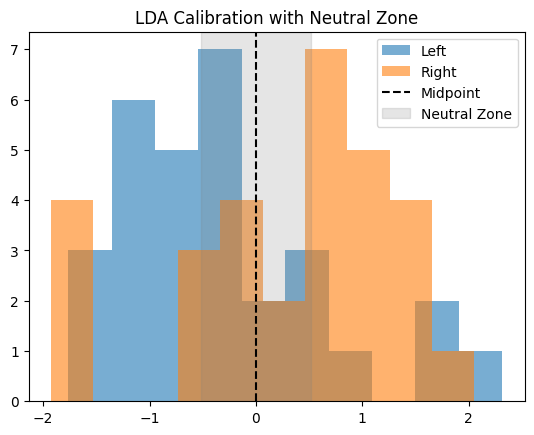

In [9]:
model = calibrate_from_npz(
    "../MIRepNet/data/mi_dataset.npz",
    fs=250,
    margin_factor=0.5,
    show_kpi=True,
    show_lda=True
)

In [11]:
predictions = lda_predict_from_npz("../MIRepNet/data/mi_dataset.npz", model)
print(predictions)

[1 0 0 0 0 2 1 0 1 2 1 2 2 2 0 1 1 1 1 0 1 0 0 1 2 1 1 2 2 0 0 1 0 2 1 0 2
 0 2 1 1 1 2 2 1 1 2 0 0 0 1 2 2 0 2 1 2 2 0 1]
